## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
 
# Tema oscuro moderno — funciona en cualquier version de matplotlib
plt.style.use("dark_background")
 
COLORES = {
    "Alta rotación" : "#4C9BE8",
    "Intermitente"  : "#F5A623",
    "Esporádico"    : "#E84C4C",
    "acento"        : "#2ECC71",
    "neutro"        : "#A0AEC0",
    "fondo"         : "#1A1A2E",
}


In [3]:
def cargar_archivos():
    ruta = r"C:\Users\david\Documents\M5 challenge"

    df_sales_validation = pd.read_csv(ruta +"\sales_train_validation.csv")
    df_calendar = pd.read_csv(ruta + "\calendar.csv")
    df_sell = pd.read_csv(ruta+"\sell_prices.csv")

    return df_sales_validation, df_calendar, df_sell

df_sales_validation, df_calendar, df_sell = cargar_archivos()

## 2. Formateo de datasets

In [4]:
def formato_sales(df_sales_validation):
    # Convertir columnas de identidad a tipo 'category'

    columnas_id = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
    columnas_dias = [col for col in df_sales_validation.columns if col.startswith("d_")]

    for col in columnas_id:
        df_sales_validation[col] = df_sales_validation[col].astype("category")

    return df_sales_validation

df_sales_validation = formato_sales(df_sales_validation)

In [5]:
def formato_calendar(df_calendar):
    # Convertir date a tipo 'datetime', rellenar Nans con 'No event' y convertir a tipo 'category', quitar columnas innecesarias

    df_calendar["date"] = pd.to_datetime(df_calendar["date"], format="%Y-%m-%d", errors="coerce")

    columnas_eventos = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
    for col in columnas_eventos:
        df_calendar[col] = df_calendar[col].fillna("No event").astype("category")

    columnas_string = ["weekday", "d"]
    for col in columnas_string:
        df_calendar[col] = df_calendar[col].astype("category")

    df_calendar = df_calendar.drop(columns=["wday", "month", "year"])

    return df_calendar

df_calendar = formato_calendar(df_calendar)

In [6]:
def formato_prices(df_sell):
    # Convertir columnas de texto a tipo 'category'

    columnas_string = ["store_id", "item_id"]
    for col in columnas_string:
        df_sell[col] = df_sell[col].astype("category")

    return df_sell

df_sell = formato_prices(df_sell)

---
## 3. Calidad de datos


### 3.1 Duplicados

In [7]:
# Un duplicado aqui significaria que el mismo SKU en la misma tienda aparece dos veces

print("Duplicados en sales:", df_sales_validation.duplicated().sum())
print("Duplicados en calendar:", df_calendar.duplicated().sum())
print("Duplicados en prices:", df_sell.duplicated().sum())

Duplicados en sales: 0
Duplicados en calendar: 0
Duplicados en prices: 0


### 3.2 Valores nulos

In [8]:
# Si hay nulos aqui no podriamos agrupar correctamente por categoria o tienda

columnas_id = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

print("Nulos en columnas de identidad (sales):")
print(df_sales_validation[columnas_id].isnull().sum())

Nulos en columnas de identidad (sales):
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64


In [9]:
# Revisamos nulos en calendar

print("Nulos en calendar:")
print(df_calendar.isnull().sum())

Nulos en calendar:
date            0
wm_yr_wk        0
weekday         0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64


In [10]:
# Checamos nulos en prices

print("Nulos en prices:")
print(df_sell.isnull().sum())

Nulos en prices:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


### 3.3 Valores unicos por columna de id
Nos sirve para confirmar que la jerarquía del dataset es la esperada

In [11]:
for col in columnas_id:
    print(f"{col:}:{df_sales_validation[col].nunique():} valores unicos")

id:30490 valores unicos
item_id:3049 valores unicos
dept_id:7 valores unicos
cat_id:3 valores unicos
store_id:10 valores unicos
state_id:3 valores unicos


In [12]:
# Verificamos exactamente cuales son esos valores unicos para cada dimension

print("Categorias:", df_sales_validation["cat_id"].cat.categories.tolist())
print("Estados:", df_sales_validation["state_id"].cat.categories.tolist())
print("Tiendas:", df_sales_validation["store_id"].cat.categories.tolist())
print("Departamentos:", df_sales_validation["dept_id"].cat.categories.tolist())

Categorias: ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Estados: ['CA', 'TX', 'WI']
Tiendas: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Departamentos: ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


### 3.4 Ceros en ventas
Los ceros pueden significar que el producto existia pero no se vendio ese dia


In [13]:
# Clasificamos SKUs segun que tan seguido venden

columnas_dias = [col for col in df_sales_validation.columns if col.startswith("d_")]
pct_ceros_por_sku = (df_sales_validation[columnas_dias] == 0).mean(axis=1)

print("SKUs con >80% de dias en cero (demanda esporadica):", (pct_ceros_por_sku > 0.80).sum())
print("SKUs con >50% de dias en cero (demanda intermitente):", (pct_ceros_por_sku > 0.50).sum())
print("SKUs con <10% de dias en cero (alta rotacion):", (pct_ceros_por_sku < 0.10).sum())

SKUs con >80% de dias en cero (demanda esporadica): 11783
SKUs con >50% de dias en cero (demanda intermitente): 23916
SKUs con <10% de dias en cero (alta rotacion): 353


In [14]:
skus_ejemplo = [
    {"item_id": "FOODS_3_127",     "store_id": "CA_1", "tipo": "Alta rotación"},
    {"item_id": "HOUSEHOLD_2_001", "store_id": "CA_2", "tipo": "Intermitente"},
    {"item_id": "HOBBIES_1_091",   "store_id": "TX_2", "tipo": "Esporádico"},
]
 
columnas_dias      = [col for col in df_sales_validation.columns if col.startswith("d_")]
columnas_identidad = ["item_id", "store_id"]
 
series = []
 
for sku in skus_ejemplo:
    fila = df_sales_validation[
        (df_sales_validation["item_id"] == sku["item_id"]) &
        (df_sales_validation["store_id"] == sku["store_id"])
    ]
    fila_long = fila.melt(
        id_vars    = columnas_identidad,
        value_vars = columnas_dias,
        var_name   = "d",
        value_name = "unidades_vendidas"
    )
    fila_long = fila_long.merge(df_calendar[["d", "date"]], on="d", how="left")
    fila_long["tipo"] = sku["tipo"]
    series.append(fila_long)
 
df_plot = pd.concat(series, ignore_index=True)
df_plot = df_plot[df_plot["date"].dt.year == 2015].sort_values("date")
 
print("Datos listos:", df_plot.shape)

Datos listos: (1095, 6)


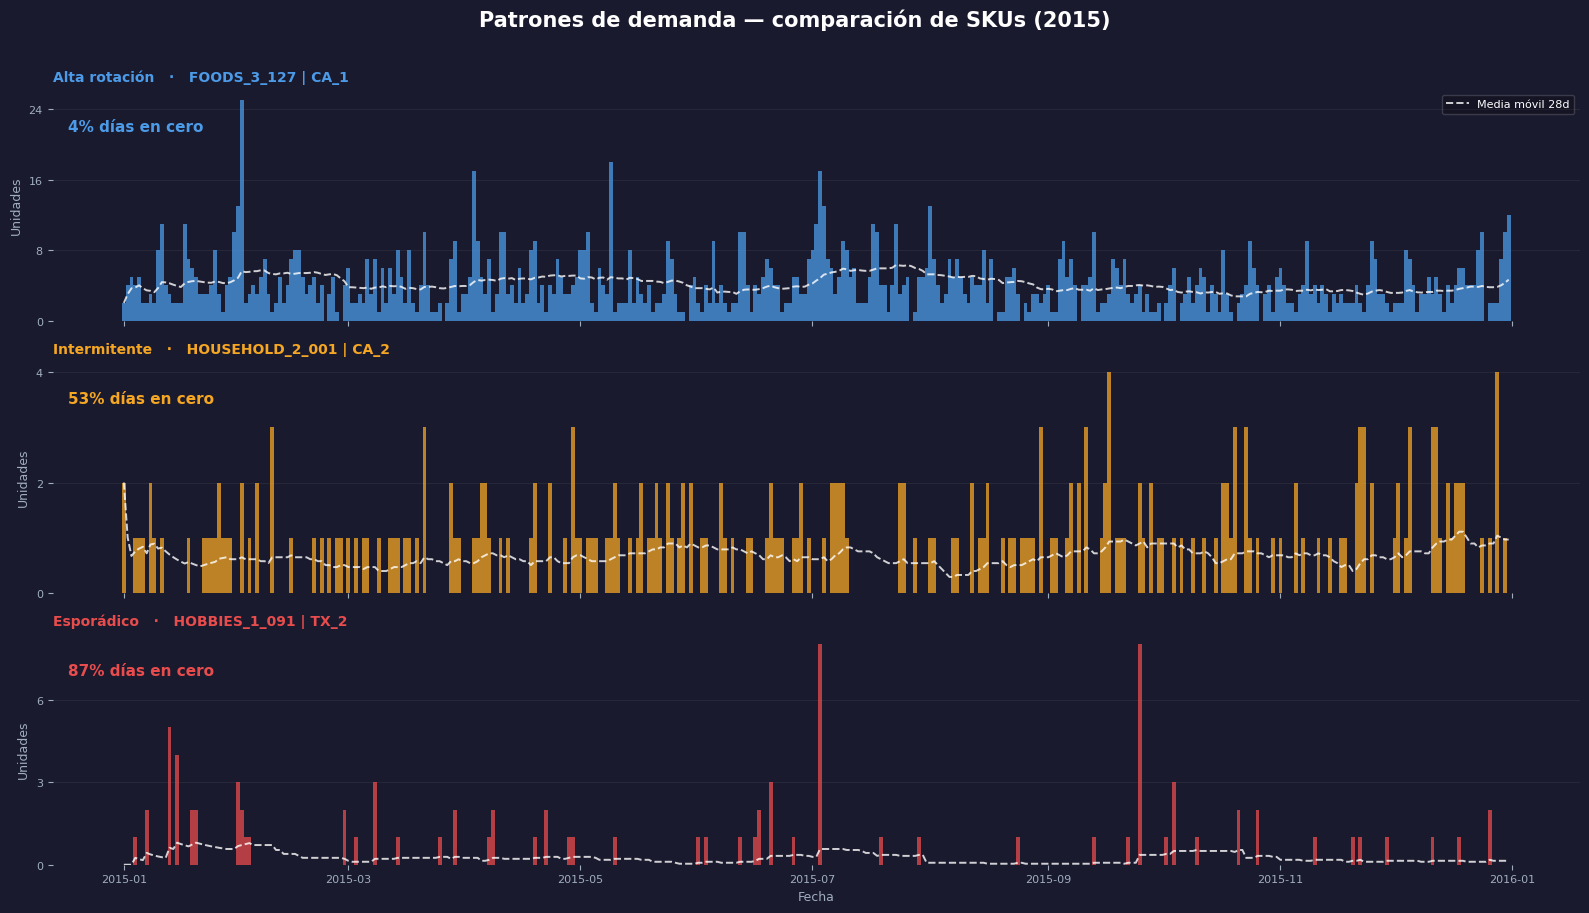

In [15]:
fig, axes = plt.subplots(
    3, 1, figsize=(16, 9),
    sharex=True,
    facecolor=COLORES["fondo"]
)
fig.suptitle(
    "Patrones de demanda — comparación de SKUs (2015)",
    fontsize=15, fontweight="bold", color="white", y=1.01
)
 
for i, sku in enumerate(skus_ejemplo):
    ax        = axes[i]
    df_sku    = df_plot[df_plot["tipo"] == sku["tipo"]].copy()
    color     = COLORES[sku["tipo"]]
    pct_ceros = (df_sku["unidades_vendidas"] == 0).mean()
 
    ax.set_facecolor(COLORES["fondo"])
 
    # Barras de ventas diarias
    ax.bar(
        df_sku["date"],
        df_sku["unidades_vendidas"],
        color = color,
        width = 1,
        alpha = 0.75,
        zorder= 2
    )
 
    # Media movil 28 dias encima de las barras
    media_movil = df_sku["unidades_vendidas"].rolling(28, min_periods=1).mean()
    ax.plot(
        df_sku["date"], media_movil,
        color     = "white",
        linewidth = 1.4,
        linestyle = "--",
        alpha     = 0.8,
        zorder    = 3,
        label     = "Media móvil 28d"
    )
 
    # Etiqueta de % de ceros — esquina superior izquierda
    ax.text(
        0.01, 0.82,
        f"{pct_ceros:.0%} días en cero",
        transform  = ax.transAxes,
        fontsize   = 11,
        fontweight = "bold",
        color      = color,
    )
 
    # Titulo del subplot con el nombre del SKU
    ax.set_title(
        f"{sku['tipo']}   ·   {sku['item_id']} | {sku['store_id']}",
        fontsize   = 10,
        color      = color,
        loc        = "left",
        fontweight = "bold",
        pad        = 6
    )
 
    ax.set_ylabel("Unidades", color=COLORES["neutro"], fontsize=9)
    ax.tick_params(colors=COLORES["neutro"], labelsize=8)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=4))
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.grid(axis="y", color="white", alpha=0.06, linewidth=0.8)
 
    if i == 0:
        ax.legend(fontsize=8, loc="upper right", framealpha=0.2)
 
axes[-1].set_xlabel("Fecha", color=COLORES["neutro"], fontsize=9)
 
plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# SECCIÓN 3.4 — Demanda intermitente
# Pega cada bloque en una celda separada de tu notebook
# =============================================================================


# ── CELDA 1 — imports ─────────────────────────────────────────────────────────

# pip install plotly  (si no lo tienes instalado)

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np



# ── CELDA 2 — preparar series de los 3 SKUs ───────────────────────────────────

skus_ejemplo = [
    {"item_id": "FOODS_3_127",     "store_id": "CA_1", "tipo": "Alta rotación"},
    {"item_id": "HOUSEHOLD_2_001", "store_id": "CA_2", "tipo": "Intermitente"},
    {"item_id": "HOBBIES_1_091",   "store_id": "TX_2", "tipo": "Esporádico"},
]

colores = {
    "Alta rotación" : "#4C9BE8",
    "Intermitente"  : "#E8A44C",
    "Esporádico"    : "#E84C4C",
}

columnas_dias      = [col for col in df_sales_validation.columns if col.startswith("d_")]
columnas_identidad = ["item_id", "store_id"]

series = []

for sku in skus_ejemplo:
    fila = df_sales_validation[
        (df_sales_validation["item_id"] == sku["item_id"]) &
        (df_sales_validation["store_id"] == sku["store_id"])
    ]

    fila_long = fila.melt(
        id_vars    = columnas_identidad,
        value_vars = columnas_dias,
        var_name   = "d",
        value_name = "unidades_vendidas"
    )

    fila_long = fila_long.merge(df_calendar[["d", "date"]], on="d", how="left")
    fila_long["tipo"] = sku["tipo"]
    series.append(fila_long)

df_plot = pd.concat(series, ignore_index=True)
df_plot = df_plot[df_plot["date"].dt.year == 2015].sort_values("date")

print("Datos listos:", df_plot.shape)


# ── CELDA 3 — grafica de series de tiempo ─────────────────────────────────────

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        f"Alta rotación  —  FOODS_3_127 | CA_1",
        f"Intermitente   —  HOUSEHOLD_2_001 | CA_2",
        f"Esporádico     —  HOBBIES_1_091 | TX_2",
    ],
    vertical_spacing=0.08
)

for i, sku in enumerate(skus_ejemplo, start=1):
    df_sku    = df_plot[df_plot["tipo"] == sku["tipo"]].copy()
    pct_ceros = (df_sku["unidades_vendidas"] == 0).mean()
    color     = colores[sku["tipo"]]

    fig.add_trace(
        go.Bar(
            x            = df_sku["date"],
            y            = df_sku["unidades_vendidas"],
            name         = sku["tipo"],
            marker_color = color,
            opacity      = 0.8,
            hovertemplate= "Fecha: %{x}<br>Unidades: %{y}<extra></extra>",
            showlegend   = (i == 1)
        ),
        row=i, col=1
    )

    media_movil = df_sku["unidades_vendidas"].rolling(28, min_periods=1).mean()

    fig.add_trace(
        go.Scatter(
            x            = df_sku["date"],
            y            = media_movil,
            mode         = "lines",
            name         = "Media móvil 28d",
            line         = dict(color="#1a1a2e", width=1.5, dash="dash"),
            hovertemplate= "Media móvil: %{y:.2f}<extra></extra>",
            showlegend   = (i == 1)
        ),
        row=i, col=1
    )

    fig.add_annotation(
        text      = f"{pct_ceros:.0%} días en cero",
        xref      = "paper",
        yref      = f"y{i}",
        x         = 0.01,
        y         = df_sku["unidades_vendidas"].max() * 0.85,
        showarrow = False,
        font      = dict(size=11, color=color, family="Arial Black"),
    )

fig.update_layout(
    title      = "Patrones de demanda — comparación de SKUs (2015)",
    height     = 600,
    hovermode  = "x unified",
    bargap     = 0,
    legend     = dict(orientation="h", y=-0.08),
    plot_bgcolor="#f8f9fa",
)

fig.update_yaxes(title_text="Unidades")
fig.update_xaxes(title_text="Fecha", row=3, col=1)

fig.show()


# ── CELDA 4 — histograma de % de ceros para todos los SKUs ────────────────────

pct_ceros_por_sku = (df_sales_validation[columnas_dias] == 0).mean(axis=1) * 100

n_alta  = (pct_ceros_por_sku <  50).sum()
n_inter = ((pct_ceros_por_sku >= 50) & (pct_ceros_por_sku < 80)).sum()
n_espo  = (pct_ceros_por_sku >= 80).sum()

fig = px.histogram(
    pct_ceros_por_sku,
    nbins                  = 50,
    color_discrete_sequence= ["#4C9BE8"],
    opacity                = 0.8,
    labels                 = {"value": "% de días en cero"},
)

fig.add_vline(
    x=50, line_dash="dash", line_color="#E8A44C", line_width=2,
    annotation_text=f"Intermitente >50%<br>{n_inter:,} SKUs",
    annotation_font_color="#E8A44C"
)

fig.add_vline(
    x=80, line_dash="dash", line_color="#E84C4C", line_width=2,
    annotation_text=f"Esporádico >80%<br>{n_espo:,} SKUs",
    annotation_font_color="#E84C4C"
)

fig.add_annotation(
    x=25, y=1800,
    text=f"Alta rotación <50%<br><b>{n_alta:,} SKUs</b>",
    showarrow=False,
    font=dict(color="#4C9BE8", size=11)
)

fig.update_layout(
    title       = "Distribución del % de días en cero — 30,490 SKUs",
    xaxis_title = "% de días con cero ventas",
    yaxis_title = "Número de SKUs",
    height      = 400,
    showlegend  = False,
    plot_bgcolor= "#f8f9fa",
)

fig.show()


# =============================================================================
# SECCIÓN 3.5 — Outliers en precios
# =============================================================================


# ── CELDA 5 — calcular limites IQR ────────────────────────────────────────────

Q1  = df_sell["sell_price"].quantile(0.25)
Q3  = df_sell["sell_price"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
mediana         = df_sell["sell_price"].median()

print(f"Q1 / Q3         : ${Q1:.2f} / ${Q3:.2f}")
print(f"IQR             : ${IQR:.2f}")
print(f"Límite superior : ${limite_superior:.2f}")
print(f"Outliers        : {(df_sell['sell_price'] > limite_superior).sum():,} registros")


# ── CELDA 6 — boxplot + histograma de precios ─────────────────────────────────

percentil_99    = df_sell["sell_price"].quantile(0.99)
precios_acotado = df_sell[df_sell["sell_price"] <= percentil_99]["sell_price"]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Boxplot", f"Histograma (acotado al percentil 99 — máx ${percentil_99:.2f})")
)

fig.add_trace(
    go.Box(
        x            = df_sell["sell_price"],
        name         = "sell_price",
        marker_color = "#4C9BE8",
        boxpoints    = "outliers",
        marker       = dict(color="#E84C4C", opacity=0.3, size=3),
        hovertemplate= "Precio: $%{x:.2f}<extra></extra>"
    ),
    row=1, col=1
)

fig.add_vline(
    x=limite_superior, line_dash="dash", line_color="#E84C4C",
    annotation_text=f"Límite IQR ${limite_superior:.2f}",
    annotation_font_color="#E84C4C",
    row=1, col=1
)

fig.add_trace(
    go.Histogram(
        x            = precios_acotado,
        nbinsx       = 60,
        name         = "sell_price",
        marker_color = "#4C9BE8",
        opacity      = 0.8,
        hovertemplate= "Precio: $%{x:.2f}<br>Frecuencia: %{y:,}<extra></extra>"
    ),
    row=1, col=2
)

fig.add_vline(
    x=mediana, line_dash="dash", line_color="#2ECC71", line_width=1.5,
    annotation_text=f"Mediana ${mediana:.2f}",
    annotation_font_color="#2ECC71",
    row=1, col=2
)

fig.add_vline(
    x=limite_superior, line_dash="dash", line_color="#E84C4C", line_width=1.5,
    annotation_text=f"Límite IQR ${limite_superior:.2f}",
    annotation_font_color="#E84C4C",
    row=1, col=2
)

fig.update_layout(
    title       = "Distribución de precios — sell_price",
    height      = 380,
    showlegend  = False,
    plot_bgcolor= "#f8f9fa",
)

fig.update_xaxes(tickprefix="$")
fig.update_yaxes(title_text="Frecuencia", row=1, col=2)

fig.show()


# ── CELDA 7 — boxplot por categoria ───────────────────────────────────────────

df_sell["cat_id"] = df_sell["item_id"].astype(str).str.split("_").str[0]

fig = px.box(
    df_sell,
    x         = "sell_price",
    y         = "cat_id",
    color     = "cat_id",
    points    = "outliers",
    color_discrete_map = {
        "FOODS"    : "#4C9BE8",
        "HOBBIES"  : "#E8A44C",
        "HOUSEHOLD": "#4CE87A",
    },
    labels    = {"sell_price": "Precio ($)", "cat_id": "Categoría"},
    hover_data= {"item_id": True, "store_id": True, "sell_price": True}
)

fig.add_vline(
    x=limite_superior, line_dash="dash", line_color="#E84C4C", line_width=1.5,
    annotation_text=f"Límite IQR ${limite_superior:.2f}",
    annotation_font_color="#E84C4C"
)

fig.update_layout(
    title      = "Distribución de precios por categoría",
    height     = 350,
    showlegend = False,
    plot_bgcolor="#f8f9fa",
)

fig.update_xaxes(tickprefix="$")

fig.show()

Datos listos: (1095, 6)


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [17]:
import nbformat
print(nbformat.__version__) # Should be 4.2.0 or higher

ModuleNotFoundError: No module named 'nbformat'

### 3.5 Outliers en precios
Revisamos el rango de precios para detectar valores extremos que puedan distorsionar el análisis de revenue.

In [ ]:
print("Estadisticas de sell_price:")
print(df_sell["sell_price"].describe().round(2))

Estadisticas de sell_price:
count    6841121.00
mean           4.41
std            3.41
min            0.01
25%            2.18
50%            3.47
75%            5.84
max          107.32
Name: sell_price, dtype: float64


In [ ]:
# Precios sobre el percentil 99 — los revisamos para decidir si son errores o productos reales

percentil_99 = df_sell["sell_price"].quantile(0.99)
precios_outlier = df_sell[df_sell["sell_price"] > percentil_99]

print(f"Percentil 99: ${percentil_99:.2f}")
print(f"Registros sobre percentil 99: {len(precios_outlier):,}")
print()
print("Items con precio maximo:")
print(df_sell.nlargest(5, "sell_price")[["item_id", "store_id", "sell_price"]])

Percentil 99: $17.92
Registros sobre percentil 99: 68,317

Items con precio maximo:
                 item_id store_id  sell_price
6485945  HOUSEHOLD_2_406     WI_3      107.32
6485946  HOUSEHOLD_2_406     WI_3      107.32
6485947  HOUSEHOLD_2_406     WI_3      107.32
5805271  HOUSEHOLD_2_406     WI_2       61.46
5805272  HOUSEHOLD_2_406     WI_2       61.46


In [ ]:
# Precios extremadamente bajos — pueden ser errores de captura o promociones agresivas

print("Items con precio minimo:")
print(df_sell.nsmallest(5, "sell_price")[["item_id", "store_id", "sell_price"]])

Items con precio minimo:
                 item_id store_id  sell_price
225727   HOUSEHOLD_1_443     CA_1        0.01
1394085    HOBBIES_1_261     CA_3        0.01
1394086    HOBBIES_1_261     CA_3        0.01
1394087    HOBBIES_1_261     CA_3        0.01
2617306      FOODS_3_413     CA_4        0.01


---
## 4. Joins — construir el dataset analítico

Para poder analizar ventas por fecha real, necesitamos transformar `df_sales_validation` de formato **wide** (1 fila por SKU, 1 columna por día) a formato **long** (1 fila por SKU × día).

Luego hacemos dos joins:
- **Sales + Calendar** → nos trae la fecha real, eventos y flags SNAP
- **+ Prices** → nos trae el precio semanal para calcular revenue

### 4.1 Melt: wide → long

In [ ]:
columnas_identidad = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
columnas_dias = [col for col in df_sales_validation.columns if col.startswith("d_")]

# Cada fila pasa de tener 1913 columnas de dias a tener una columna 'd' y una columna 'unidades_vendidas'
# El resultado son ~58 millones de filas (30,490 SKUs x 1,913 dias)

df_sales_long = df_sales_validation.melt(
    id_vars    = columnas_identidad,
    value_vars = columnas_dias,
    var_name   = "d",
    value_name = "unidades_vendidas"
)

df_sales_long["d"] = df_sales_long["d"].astype("category")

print("Shape despues del melt:", df_sales_long.shape)
df_sales_long.head()

### 4.2 Join con calendar — traer fechas reales

In [ ]:
# La llave de union es la columna 'd' (d_1, d_2, ... d_1913)
# Esto nos trae: date, weekday, eventos, flags SNAP, y wm_yr_wk (que usaremos para unir precios)

df_sales_long = df_sales_long.merge(
    df_calendar,
    on  = "d",
    how = "left"
)

print("Shape despues de join con calendar:", df_sales_long.shape)
df_sales_long.head()

In [ ]:
# Verificamos que no hayan quedado nulos en la columna 'date' despues del join
# Un nulo aqui significaria que hay un dia en ventas que no existe en el calendario

print("Nulos en 'date' despues del join:", df_sales_long["date"].isnull().sum())

### 4.3 Join con prices — traer precio semanal

In [ ]:
# La llave de union es store_id + item_id + wm_yr_wk
# El precio es semanal, por eso usamos wm_yr_wk y no la fecha exacta
# Cada precio se va a repetir 7 veces (una por cada dia de la semana) — eso es correcto

df_sales_long = df_sales_long.merge(
    df_sell,
    on  = ["store_id", "item_id", "wm_yr_wk"],
    how = "left"
)

print("Shape despues de join con prices:", df_sales_long.shape)
df_sales_long.head()

In [ ]:
# Verificamos cuantos registros quedaron sin precio despues del join
# Esto ocurre cuando un item no tenia precio registrado en ciertas semanas
# (producto nuevo, descontinuado, o semana fuera del rango de precios)

nulos_precio = df_sales_long["sell_price"].isnull().sum()
total        = len(df_sales_long)

print(f"Registros sin precio : {nulos_precio:,}  ({nulos_precio / total * 100:.2f}% del total)")

### 4.4 Calcular revenue

In [ ]:
# Revenue = unidades vendidas x precio
# Donde no hay precio, el revenue quedara como NaN — lo dejamos asi para no inventar datos

df_sales_long["revenue"] = df_sales_long["unidades_vendidas"] * df_sales_long["sell_price"]

print("Columnas finales:", df_sales_long.columns.tolist())
print("\nShape final:", df_sales_long.shape)

In [ ]:
# Vista general del dataset analitico final

df_sales_long.info()

In [ ]:
df_sales_long.head(10)